# Black-box job-shop scheduling

An LLM (Qwen2.5-Coder-7B-Instruct, rank-8 LoRA) reads a job-shop instance and writes a JSON plan that assigns one
dispatch rule to each of 4 machine groups, from a menu of 5: 625 possible plans. A deterministic scheduler builds the
schedule, and the black box returns the instance's lower bound divided by the makespan (a reward between 0 and 1).


The whole pipeline is `scripts/final_exp.sh`. It needs Linux, 8 GPUs, Docker for the solver's validator, and the model
weights; see `README.md` ("Installation and data") for the setup. It takes days. The results file is in git, so the
plot below works without running anything.

In [1]:
import os, sys, json, subprocess, numpy as np, matplotlib.pyplot as plt
from scipy import stats

RUN    = False                                         # True: run the whole pipeline; finished stages are skipped
DATA   = os.environ.get("JOBSHOP_DATA", os.path.abspath("data"))   # feature cache, label pools, checkpoints (tens of GB)
RESULT = "results/v3-fitted400-curves-lr0.5.json"      # the curves: written by stage 7, the exact gradient added by stage 8
SEEDS  = range(10, 30)                                 # the paper's panel; the file holds seeds 10-49

In [2]:
if RUN:
    env = {**os.environ, "JOBSHOP_DATA": DATA, "PY": sys.executable}
    p = subprocess.Popen(["bash", "scripts/final_exp.sh"], env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in p.stdout: print(line, end="")
    assert p.wait() == 0, "final_exp.sh failed"
else:
    print(f"RUN = False: plotting the results in {RESULT}")

RUN = False: plotting the results in results/v3-fitted400-curves-lr0.5.json


## Results

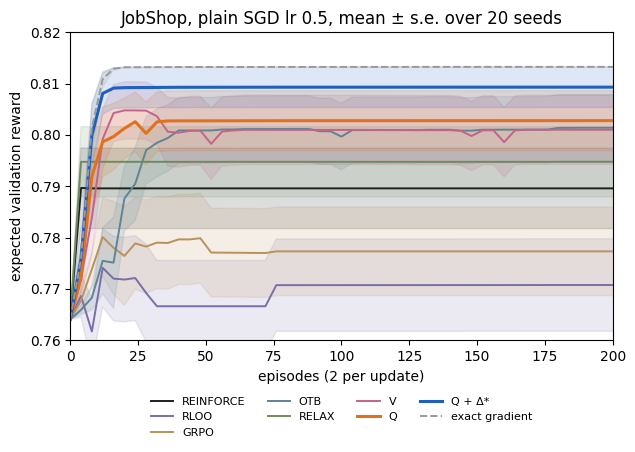

method           seeds   final  mean over the run         vs Q (paired)
exact gradient      20  0.8133             0.8125      +0.0104  p 0.085
Q + Δ*              20  0.8093             0.8086      +0.0065  p 0.377
Q                   20  0.8028             0.8021                      
OTB                 20  0.8015             0.7998      -0.0022  p 0.762
V                   20  0.8010             0.8004      -0.0017  p 0.861
RELAX               20  0.7948             0.7945      -0.0075  p 0.404
REINFORCE           20  0.7896             0.7894      -0.0127  p 0.217
GRPO                20  0.7773             0.7772      -0.0248  p 0.051
RLOO                20  0.7708             0.7703      -0.0317  p 0.010


In [3]:
d = json.load(open(RESULT))
NAMES = {"reinforce": "REINFORCE", "rloo": "RLOO", "grpo": "GRPO", "otb": "OTB", "relax": "RELAX", "vbase": "V",
         "qcv": "Q", "row_delta": "Q + Δ*", "exact_gradient": "exact gradient"}
COL = {"REINFORCE": "#1f1f1f", "RLOO": "#7a6ea8", "GRPO": "#b8925a", "OTB": "#5f8496", "LAX": "#6e8b5e", "RELAX": "#6e8b5e", "V": "#c2648a",
       "Q": "#e2711d", "Q + Δ*": "#1f5fbf", "exact gradient": "#9a9994"}                  # the paper's colors
L = max(len(v["updates"]) for v in d.values())
S = {}
for key, name in NAMES.items():
    runs = [d[k] for k in (f"seed-{s}/{key}" for s in SEEDS) if k in d and len(d[k]["updates"]) == L]   # drop runs that died early
    if runs: S[name] = np.array([r["val"] for r in runs]); x = np.array(runs[0]["updates"]) * 2      # 2 episodes per update

fig, ax = plt.subplots(figsize=(7, 4))
for name, V in S.items():
    m, se = V.mean(0), V.std(0, ddof=1) / np.sqrt(len(V))
    ax.plot(x, m, ls="--" if name == "exact gradient" else "-", lw=2.2 if name.startswith("Q") else 1.4, color=COL[name], label=name)
    ax.fill_between(x, m - se, m + se, color=COL[name], alpha=0.15)
ax.set(xlabel="episodes (2 per update)", ylabel="expected validation reward", xlim=(0, 200), ylim=(0.76, 0.82),
       title=f"JobShop, plain SGD lr 0.5, mean ± s.e. over {len(SEEDS)} seeds")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=8, frameon=False); plt.show()

print(f"{'method':16s}{'seeds':>6s}{'final':>8s}{'mean over the run':>19s}{'vs Q (paired)':>22s}")
for name, V in sorted(S.items(), key=lambda kv: -kv[1][:, -1].mean()):
    vs = ""
    if name != "Q" and len(V) == len(S["Q"]):
        a, b = V.mean(1), S["Q"].mean(1); vs = f"{(a - b).mean():+.4f}  p {stats.ttest_rel(a, b).pvalue:.3f}"
    print(f"{name:16s}{len(V):>6d}{V[:, -1].mean():>8.4f}{V.mean():>19.4f}{vs:>22s}")